## Goals
In this lab you will:
- Utilize  scikit-learn to implement linear regression using Gradient Descent

## Tools
You will utilize functions from scikit-learn as well as matplotlib and NumPy. 

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler


# Gradient Descent
Scikit-learn has a gradient descent regression model [sklearn.linear_model.SGDRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDRegressor.html#examples-using-sklearn-linear-model-sgdregressor).  Like your previous implementation of gradient descent, this model performs best with normalized inputs. [sklearn.preprocessing.StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler) will perform z-score normalization as in a previous lab. Here it is referred to as 'standard score'.

In [ ]:
def load_house_data():
    data = np.loadtxt("./data/houses.txt", delimiter=',', skiprows=1)
    X = data[:,:4]
    y = data[:,4]
    return X, y

# Load
x_train, y_train = load_house_data()
X_features = ['size(sqft)','bedrooms','floors','age']

# Scale / Normalize 
scaler = StandardScaler()
x_norm = scaler.fit_transform(x_train)
print(f"Peak to Peak range by column in Raw        X:{np.ptp(x_train,axis=0)}")   
print(f"Peak to Peak range by column in Normalized X:{np.ptp(x_norm,axis=0)}")

# Train
sgdr = SGDRegressor(max_iter = 1000)
sgdr.fit(x_norm, y_train)
print(sgdr)
print(f"number of iterations completed: {sgdr.n_iter_}, number of weight updates: {sgdr.t_}")

w_norm = sgdr.coef_
b_norm = sgdr.intercept_
print(f"model parameters:                   w: {w_norm}, b:{b_norm}")
print( "model parameters from previous lab: w: [110.56 -21.27 -32.71 -37.97], b: 363.16")

# Query / Predict using training data 
y_pred_sgd = sgdr.predict(x_norm) # make a prediction using sgdr.predict()
y_pred = np.dot(x_norm, w_norm) + b_norm  # make a prediction using w,b. 
print(f"prediction using np.dot() and sgdr.predict match: {(y_pred == y_pred_sgd).all()}")

print(f"Prediction on training set using sckit model:\n{y_pred_sgd[:4]}" )
print(f"Prediction on training set using maths:\n{y_pred[:4]}" )
print(f"Target values \n{y_train[:4]}")


Peak to Peak range by column in Raw        X:[2.406e+03 4.000e+00 1.000e+00 9.500e+01]
Peak to Peak range by column in Normalized X:[5.8452591  6.13529646 2.05626214 3.68533012]
SGDRegressor()
number of iterations completed: 124, number of weight updates: 12277.0
model parameters:                   w: [110.12797492 -21.07173439 -32.48424611 -38.04705779], b:[363.16294055]
model parameters from previous lab: w: [110.56 -21.27 -32.71 -37.97], b: 363.16
prediction using np.dot() and sgdr.predict match: True
Prediction on training set:
[295.19860154 485.86049582 389.56534182 492.02301716]
Prediction on training set:
[295.19860154 485.86049582 389.56534182 492.02301716]
Target values 
[300.  509.8 394.  540. ]


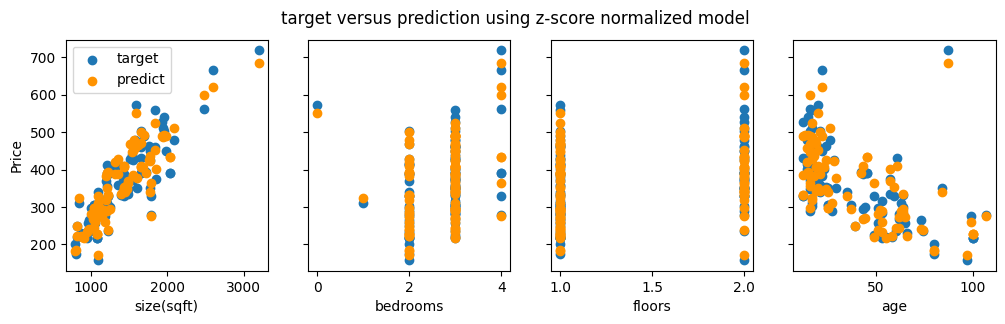

In [13]:
# plot predictions and targets vs original features    
dlc = dict(dlblue = '#0096ff', dlorange = '#FF9300', dldarkred='#C00000', dlmagenta='#FF40FF', dlpurple='#7030A0')

fig,ax=plt.subplots(1,4,figsize=(12,3),sharey=True)
for i in range(len(ax)):
    ax[i].scatter(x_train[:,i],y_train, label = 'target')
    ax[i].set_xlabel(X_features[i])
    ax[i].scatter(x_train[:,i],y_pred,color=dlc["dlorange"], label = 'predict')
ax[0].set_ylabel("Price"); ax[0].legend();
fig.suptitle("target versus prediction using z-score normalized model")
plt.show()